In [3]:
import json
from pathlib import Path

DATA_DIR = Path("/home/mahuk/chunking-thesis/data/datasets/literaryQA/default/Tasks/open_qa/test")

unique_questions = set()
files_processed = 0

for json_file in DATA_DIR.glob("*.json"):
    try:
        with open(json_file, "r", encoding="utf-8") as f:
            data = json.load(f)

        # jeśli JSON jest słownikiem: {question: ...}
        if isinstance(data, dict):
            unique_questions.update(data.keys())

        # jeśli JSON jest listą obiektów z polem "question"
        elif isinstance(data, list):
            for item in data:
                if isinstance(item, dict) and "question" in item:
                    unique_questions.add(item["question"])

        files_processed += 1

    except Exception as e:
        print(f"Błąd w {json_file}: {e}")

print(f"Przetworzono plików: {files_processed}")
print(f"Liczba unikatowych pytań: {len(unique_questions)}")

Przetworzono plików: 138
Liczba unikatowych pytań: 3785


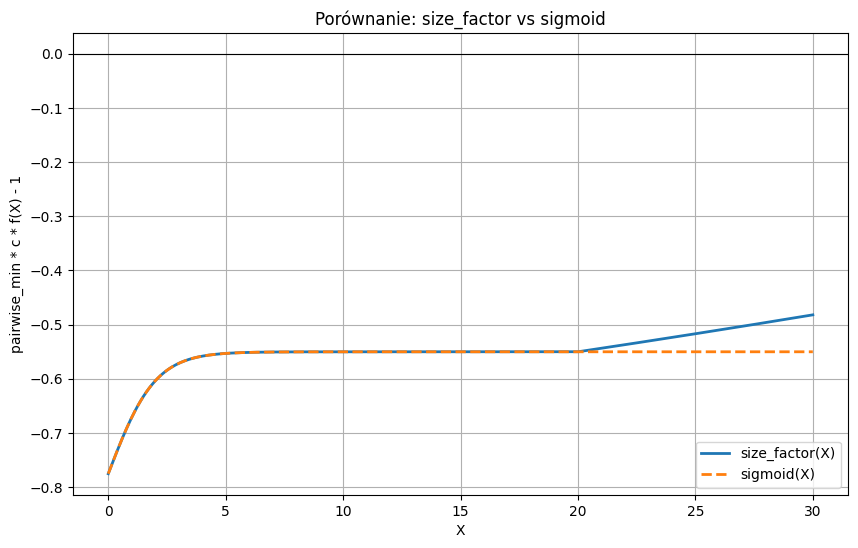

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit  # sigmoid

# --- asymetryczny softplus ---
def size_factor(n, pivot=20, steepness_left=0.02, steepness_right=0.02):
    def softplus(x, s):
        return np.log1p(np.exp(s * x))
    
    norm_at_pivot = softplus(0, 1)  # log(2)

    if n <= pivot:
        return expit(n)  # sigmoid dla lewej strony (jak w Twoim kodzie)
    else:
        return softplus(n - pivot, steepness_right) / norm_at_pivot

# wektorowa wersja size_factor
size_factor_vec = np.vectorize(size_factor)

# --- parametry ---
pairwise_min = 0.5
c = 0.9

# --- dane ---
X = np.linspace(0, 30, 500)

y_size = pairwise_min * c * size_factor_vec(X) - 1
y_sigmoid = pairwise_min * c * expit(X) - 1

# --- wykres ---
plt.figure(figsize=(10, 6))
plt.plot(X, y_size, label="size_factor(X)", linewidth=2)
plt.plot(X, y_sigmoid, label="sigmoid(X)", linewidth=2, linestyle="--")

plt.axhline(0, color="black", linewidth=0.8)
plt.title("Porównanie: size_factor vs sigmoid")
plt.xlabel("X")
plt.ylabel("pairwise_min * c * f(X) - 1")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
from pathlib import Path
import json
import pandas as pd

base_path = Path("data/chunks")

splits = {"train", "test", "validation"}

rows = []

for meta_file in base_path.rglob("meta.json"):

    rel = meta_file.relative_to(base_path)
    parts = rel.parts

    # znajdź split gdziekolwiek w ścieżce
    split = None
    for s in splits:
        if s in parts:
            split = s
            break

    if split is None:
        continue

    # dataset = pierwszy folder po data/chunks
    dataset = parts[0]

    # chunker = folder przed splitem (szukamy pozycji split)
    split_idx = parts.index(split)
    if split_idx < 2:
        continue


    with open(meta_file, "r", encoding="utf-8") as f:
        meta = json.load(f)

    rows.append({
        "dataset": dataset,
        "chunking_method": meta['chunking_method'],
        "split": split,
        "chunks_num": meta["chunks_num"],
        "avg_token_len": meta["avg_token_len"]
    })

df = pd.DataFrame(rows)

agg_df = df
required_splits = {"train", "test", "validation"}

all_rows = []

for (dataset, chunking_method), group in df.groupby(["dataset", "chunking_method"]):

    present_splits = set(group["split"])

    # jeśli nie ma wszystkich splitów -> zostaw jak jest
    if present_splits != required_splits:
        all_rows.append(group)
        continue

    # suma chunków
    total_chunks = group["chunks_num"].sum()

    # ważona średnia długość tokenów
    weighted_avg = (
        (group["avg_token_len"] * group["chunks_num"]).sum()
        / total_chunks
        if total_chunks > 0
        else 0
    )

    all_rows.append(pd.DataFrame([{
        "dataset": dataset,
        "chunking_method": chunking_method,
        "split": "all",
        "chunks_num": total_chunks,
        "avg_token_len": weighted_avg
    }]))

# nowa tabela
agg_df = pd.concat(all_rows, ignore_index=True)

In [42]:
agg_df

,dataset,chunking_method,split,chunks_num,avg_token_len
0,infiniteBenchChoice,chonkie_semantic,all,58494,199.668137
1,infiniteBenchChoice,fixed_size,all,48369,279.094234
2,infiniteBenchChoice,lumber,all,49351,236.269113
3,infiniteBenchChoice,max_min,all,49577,235.674204
4,infiniteBenchChoice,neural,all,10253,1140.498878
5,infiniteBenchChoice,recursive,all,49255,236.708639
6,infiniteBenchChoice,recursive_semantic,all,48469,240.961047
7,infiniteBenchChoice,sequential_hac,all,10595,1104.039264
8,infiniteBenchQA,chonkie_semantic,all,62369,225.448043
9,infiniteBenchQA,fixed_size,all,58366,279.279426


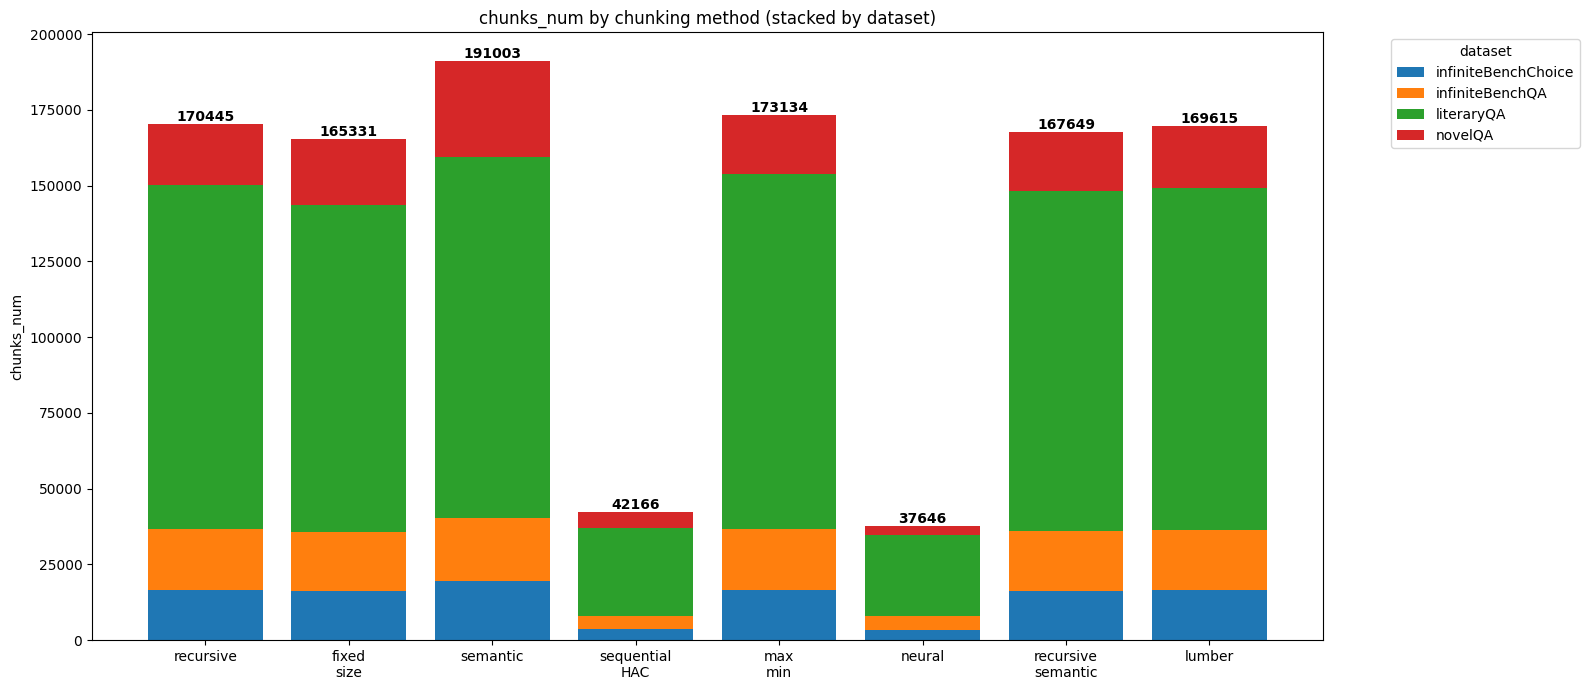

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

metric = "chunks_num"

order = [
    "recursive",
    "fixed_size",
    "chonkie_semantic",
    "sequential_hac",
    "max_min",
    "neural",
    "recursive_semantic",
    "lumber"
]

agg = df.groupby(["chunking_method", "dataset"], as_index=False)[metric].mean()
pivot = agg.pivot(index="chunking_method", columns="dataset", values=metric).fillna(0)
pivot = pivot.reindex(order)

datasets = pivot.columns.tolist()

x = range(len(pivot.index))
plt.figure(figsize=(16, 7))

bottom = [0] * len(pivot)

colors = plt.cm.tab10.colors

for i, dataset in enumerate(datasets):
    values = pivot[dataset].values

    plt.bar(
        x,
        values,
        bottom=bottom,
        label=dataset,
        color=colors[i % len(colors)]
    )

    bottom = [b + v for b, v in zip(bottom, values)]

# ---- SUMY NA GÓRZE ----
for i, total in enumerate(bottom):
    plt.text(
        i,
        total,
        f"{total:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.xticks(
    x,
    [
        "recursive",
        "fixed\nsize",
        "semantic",
        "sequential\nHAC",
        "max\nmin",
        "neural",
        "recursive\nsemantic",
        "lumber"
    ],
    rotation=0
)

plt.ylabel(metric)
plt.title(f"{metric} by chunking method (stacked by dataset)")
plt.legend(title="dataset", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [60]:
from pathlib import Path
import json
import pandas as pd
from collections import defaultdict

root = Path("data/chunks")

# (dataset_name, chunker_name, split) -> list of tokens_len
agg = defaultdict(list)

for jsonl_path in root.glob("*/default/*/*/*/Books/*.jsonl"):
    parts = jsonl_path.parts

    # dopasowanie do struktury:
    dataset_name = parts[2]
    chunker_name = parts[4]
    split = parts[6]

    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            obj = json.loads(line)
            if "tokens_len" in obj:
                agg[(dataset_name, chunker_name, split)].append(obj["tokens_len"])

# budowa dataframe
rows = []
for (dataset_name, chunker_name, split), tokens_list in agg.items():
    rows.append({
        "dataset_name": dataset_name,
        "chunker_name": chunker_name,
        "split": split,
        "tokens_len_list": tokens_list
    })

df = pd.DataFrame(rows)

df = (
    df
    .groupby(["dataset_name", "chunker_name", "split"], as_index=False)
    .agg({
        "tokens_len_list": lambda lists: sum(lists, [])  # flatten list of lists
    })
)

df = df[
    (df["split"] == "all") |
    ((df["dataset_name"] == "literaryQA") & (df["split"] == "test"))
].reset_index(drop=True)

In [61]:
df.columns

Index(['dataset_name', 'chunker_name', 'split', 'tokens_len_list'], dtype='object')

/tmp/ipykernel_17318/994481830.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


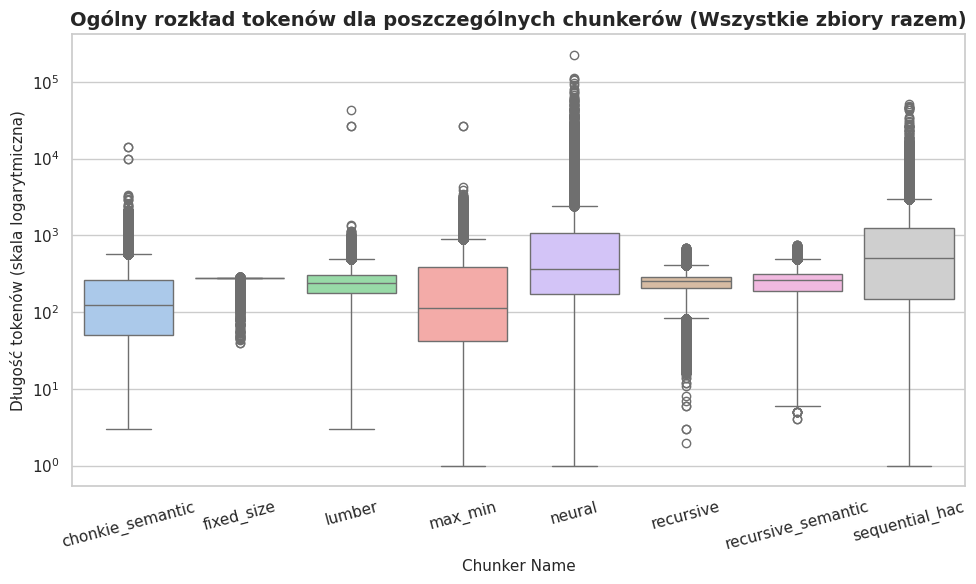

In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PRZETWARZANIE DANYCH (Explode) ---
# Rozbijamy listy z 'tokens_len_list' na pojedyncze wiersze
df_exploded = df.explode('tokens_len_list')
df_exploded['tokens_len_list'] = pd.to_numeric(df_exploded['tokens_len_list'])

# Odfiltrowujemy wartości <= 0 dla poprawnego działania logarytmu
df_exploded = df_exploded[df_exploded['tokens_len_list'] > 0]

# --- 2. TWORZENIE JEDNEGO WYKRESU ---
plt.figure(figsize=(10, 6))

# Rysujemy box plot zagregowany po wszystkich zbiorach
sns.boxplot(
    data=df_exploded, 
    x='chunker_name', 
    y='tokens_len_list', 
    palette="pastel"
)

# Włączenie skali logarytmicznej na osi Y
plt.yscale('log')

# Opisy i estetyka
plt.title("Ogólny rozkład tokenów dla poszczególnych chunkerów (Wszystkie zbiory razem)", fontsize=14, fontweight='bold')
plt.xlabel("Chunker Name", fontsize=11)
plt.ylabel("Długość tokenów (skala logarytmiczna)", fontsize=11)
plt.xticks(rotation=15) # Obrót etykiet osi X, jeśli nazwy chunkerów są długie

# --- 3. ZAPIS I WYŚWIETLENIE ---
plt.tight_layout()
plt.savefig('tokens_len_boxplot_aggregated.png', dpi=300)
plt.show()

In [ ]:
from src.tools.read.generation_result.load_generation_result import load_evaluation_results_raw
from pathlib import Path

df = load_evaluation_results_raw(
    Path("data/evaluate_generator_result")
)
df_novelqa = df.xs('novelQA', level='dataset_name')

In [4]:

print(df.index.get_level_values('dataset_name').unique())

Index(['infiniteBenchChoice', 'infiniteBenchQA', 'literaryQA'], dtype='object', name='dataset_name')


In [3]:
df_novelqa = df.xs('novelQA', level='dataset_name')
df

KeyError: 'novelQA'